In [1]:
import numpy

from src import *
import matplotlib.pyplot as plt

logger = logging.getLogger("global_logger")
logging.basicConfig(filename='../gap_handler_test.log', format='%(levelname)s: %(message)s', encoding='utf-8', filemode='w', level=logging.DEBUG)
logger.info("NEW START")
data = get_combined_data()
replay_settings = SimulationParameters("max_velocity")
replay_settings.save_to_file()
simulator = SimulatorHandler()
gap_handler = simulator.simulation_gap(settings=replay_settings, data=data, replay_mode=ExperimentMode.PARTIAL)
gap_handler_visualizer = GapHandlerVisualizer(gap_handler)

In [2]:
# define which logs to use for testing
action_name = "kick_left"
recording_date = "260108"
log_index = 4
joint_name = "y_gyro"
start_frame = 0
end_frame = -1


# extraction:   get_pos_extraction, get_vel_extraction, get_acc_extraction
# replay:       get_pos_replay, get_vel_replay, get_acc_replay
# gaps:         get_pos_gap, get_vel_gap, get_acc_gap, get_total_gap
f0 = lambda gap_object : SimulationGapData.get_pos_extraction(gap_object, [joint_name], start_frame, end_frame)
f0_name = "pos_gap"

# get_pos_gap_avg_for_joints, get_vel_gap_avg_for_joints get_acc_gap_avg_for_joints, get_total_gap_avg_for_joints
f1 = lambda gap_object : SimulationGapData.get_total_gap_for_sensors(gap_object, None, start_frame, end_frame)
f1_name = "get_total_gap_avg_for_joints"

# get_pos_gap_avg_for_frames, get_vel_gap_avg_for_frames get_acc_gap_avg_for_frames, get_total_gap_avg_for_frames
f2 = lambda gap_object : SimulationGapData.get_total_gap_for_frames(gap_object, None, start_frame, end_frame)
f2_name = "get_total_gap_avg_for_frames"

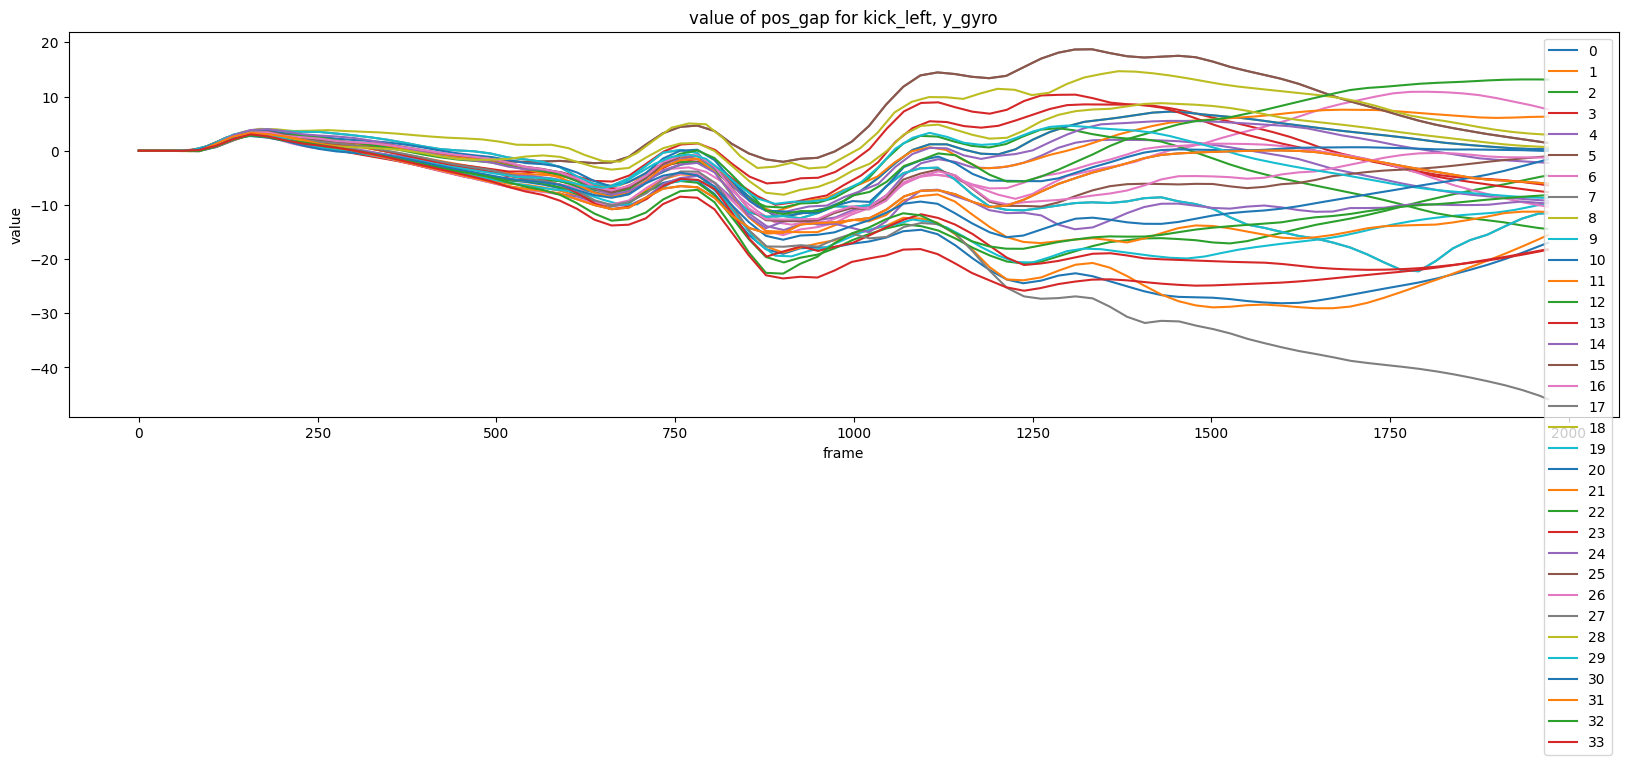

In [3]:
gap_handler_visualizer.plt_all_for_action_joint(action_name, joint_name, f0_name, f0, start_frame, end_frame)

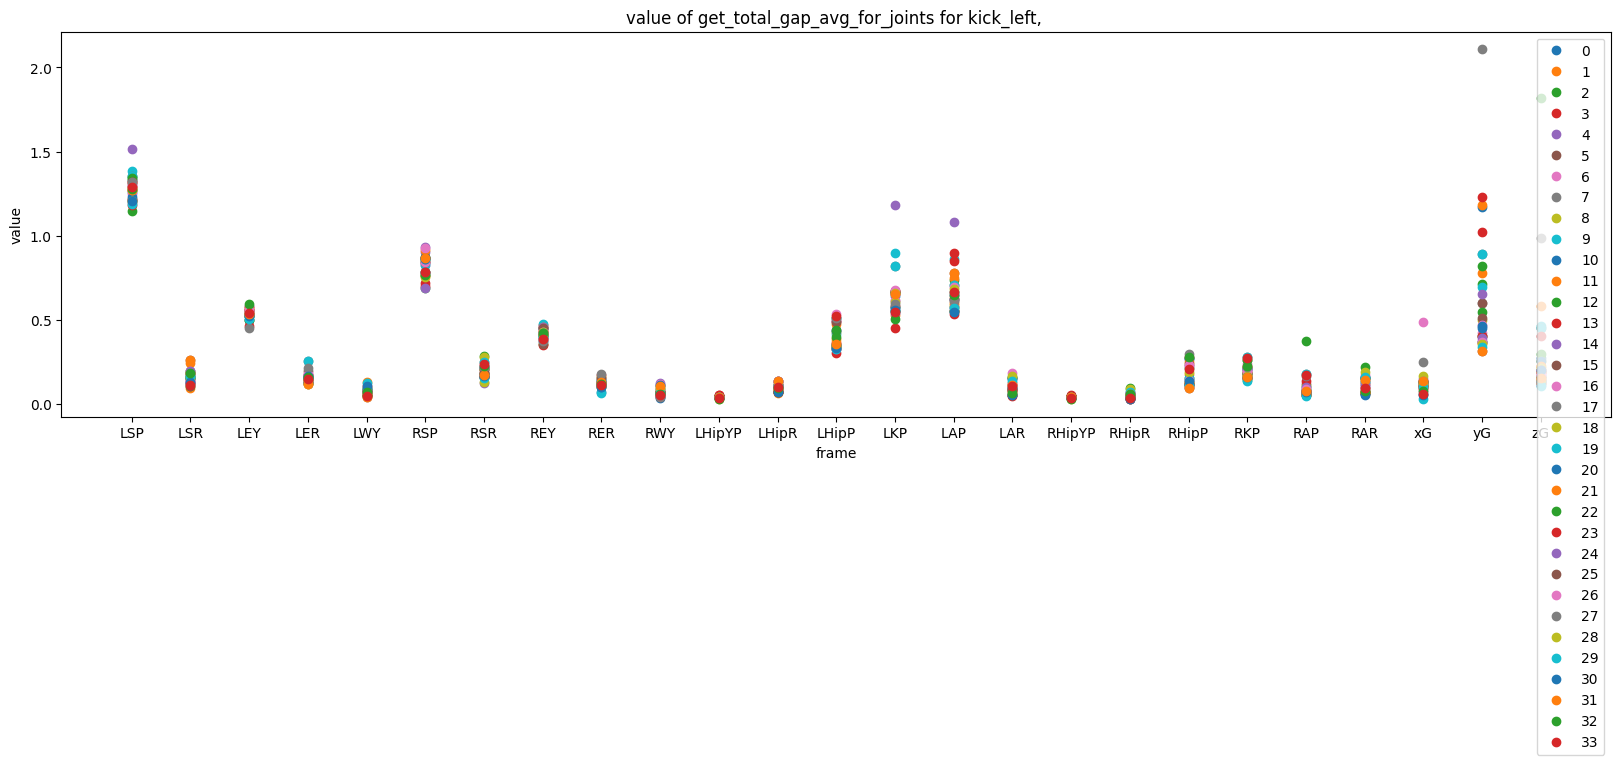

In [4]:
gap_handler_visualizer.plt_all_gap_avg_for_joints(action_name, f1_name, f1)

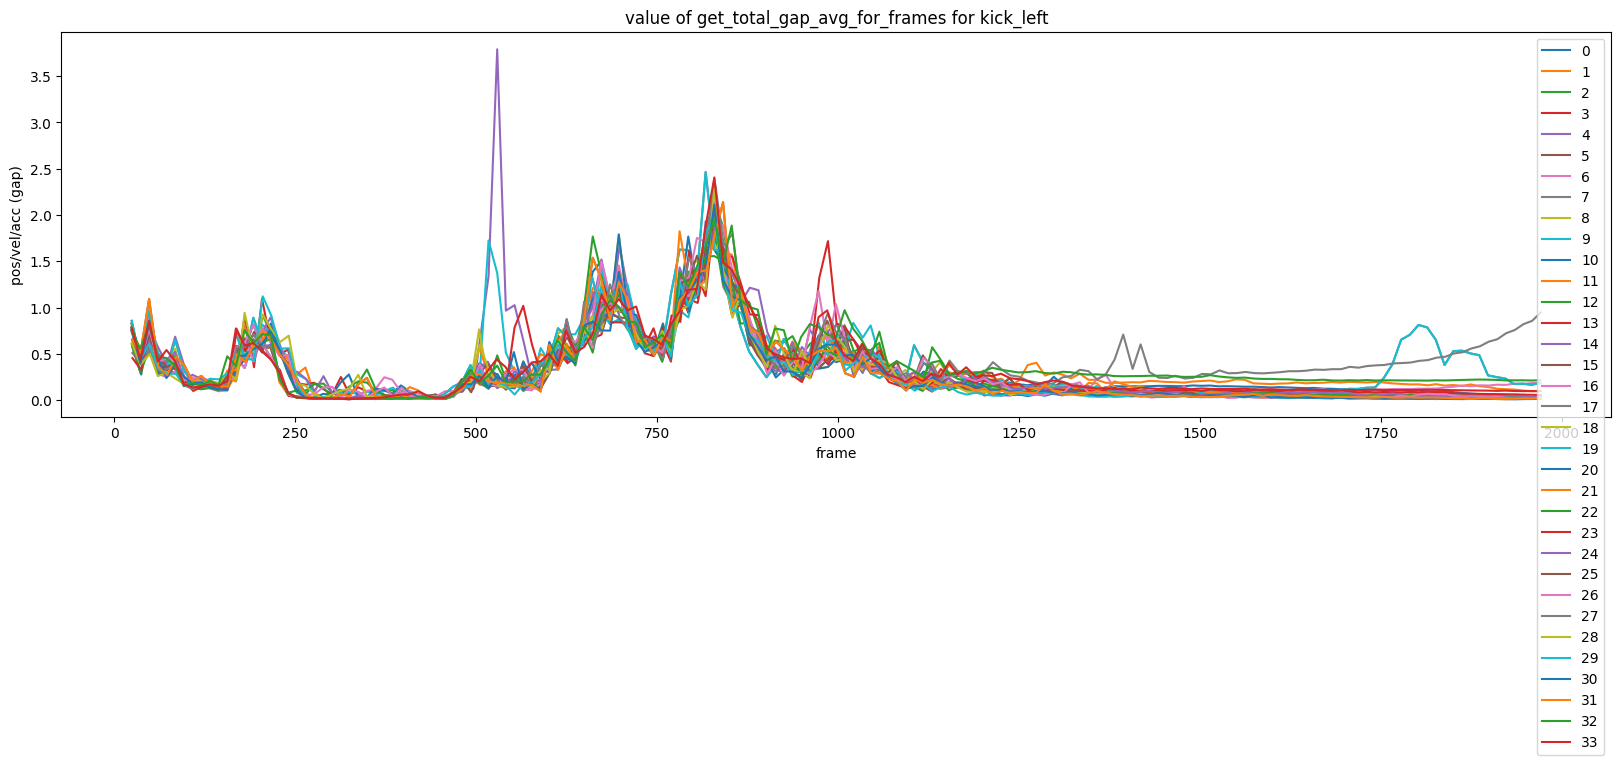

In [5]:
gap_handler_visualizer.plt_all_gap_avg_for_frames(action_name, f2_name, f2,start_frame, end_frame)

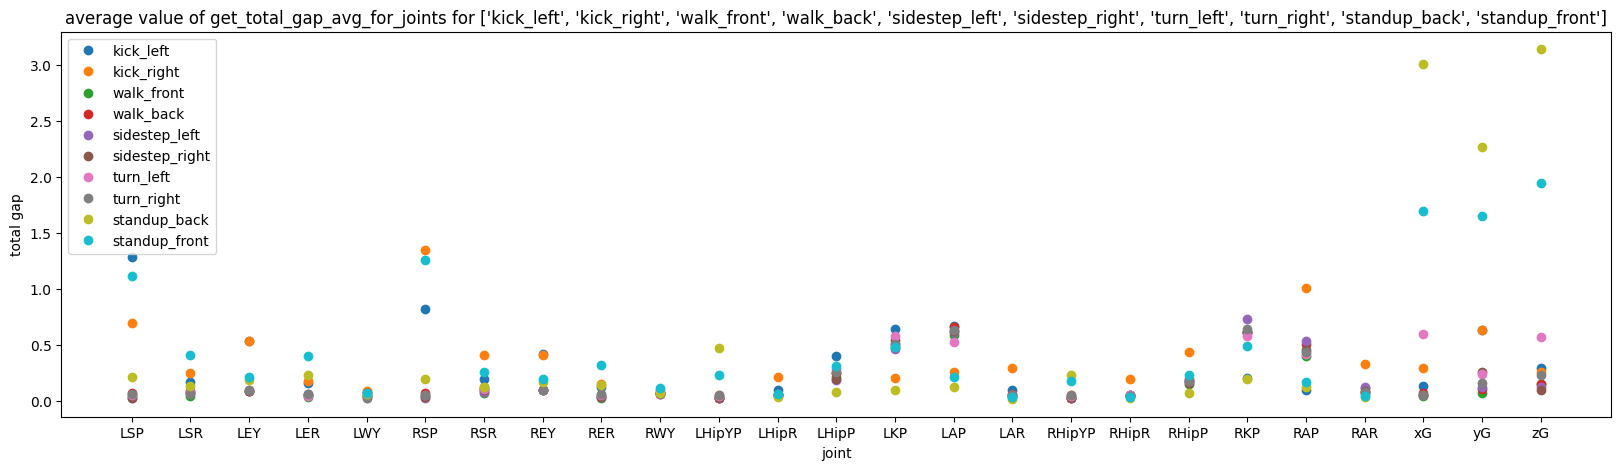

In [6]:
gap_handler_visualizer.plt_gap_avg_for_joints(f1_name, f1)

C:\Users\felix\PycharmProjects\Thesis\src\Utils\SimulationGapHandler.py:126: RuntimeWarning: Mean of empty slice
  result[action_name] = [np.nanmean(np.array(group, dtype=float)) for group in zip_longest(*partial_results, fillvalue=np.nan)]


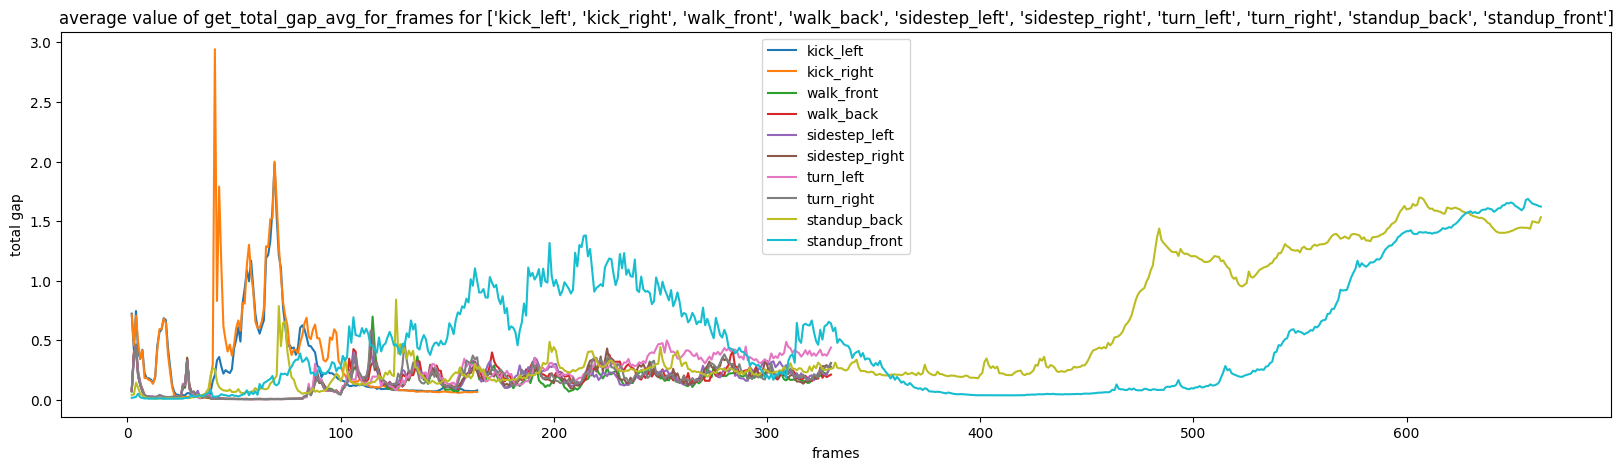

In [7]:
gap_handler_visualizer.plt_gap_avg_for_frames(f2_name, f2)

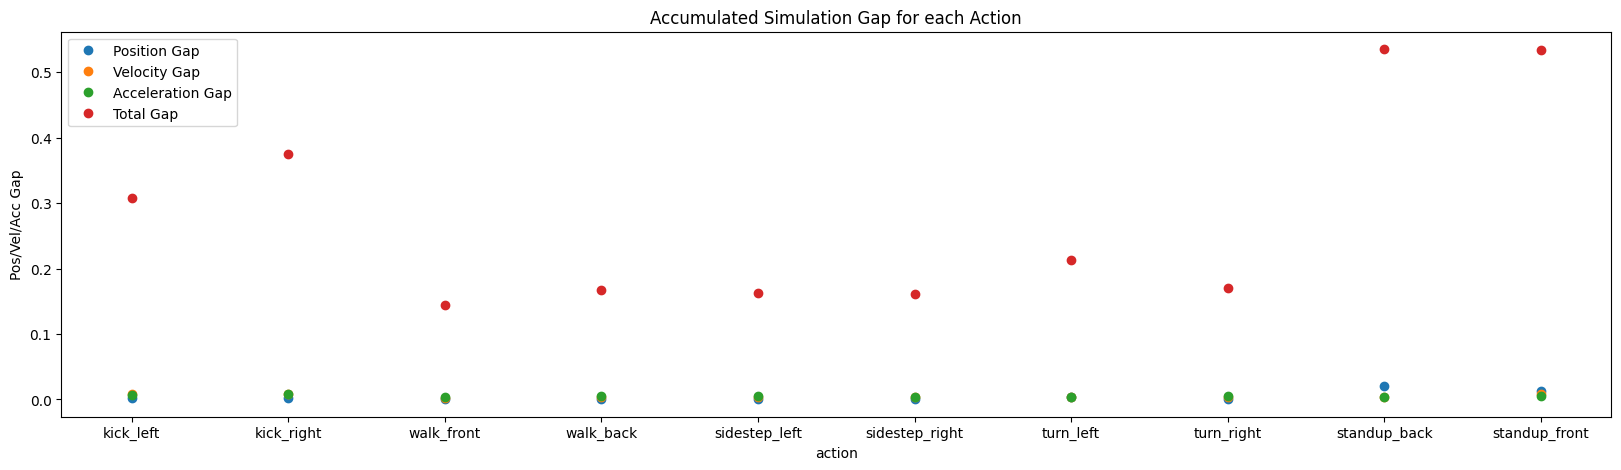

In [8]:
gap_handler_visualizer.plt_gap_avg(start_frame, end_frame)

In [9]:
#print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_pos_gap_avg(x, None, start_frame, end_frame)))
#print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_vel_gap_avg(x, None, start_frame, end_frame)))
#print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_acc_gap_avg(x, None, start_frame, end_frame)))
#print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_total_gap_avg(x, None, start_frame, end_frame)))
print(gap_handler.get_optimization_target())
for action_name in ACTION_NAMES:
    print(action_name)
    print(gap_handler.get_final_FINAL_gap_avg(lambda gap_object: SimulationGapData.get_total_gap_avg(gap_object), [action_name]))
    print()

0.29498876540459856
kick_left
0.30837864466633985

kick_right
0.3757732758279743

walk_front
0.14501753762421324

walk_back
0.16728619747494083

sidestep_left
0.16333020347350016

sidestep_right
0.16127204131777104

turn_left
0.213199897068186

turn_right
0.1701701283198824

standup_back
0.5353725023125905

standup_front
0.5332104671160752



gap_handler_visualizer